In [1]:
from langgraph.graph import MessagesState, StateGraph, END, START
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community. tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition # this is the checker for the
from langgraph.prebuilt import ToolNode

In [2]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="moonshotai/kimi-k2-instruct-0905")

In [3]:
def multiply(a:int, b:int)-> int:
    """Multiplies two integers.
    Args:
        a: The first integer.
        b: The second integer.
    Returns:
        The product of the two integers.
    """
    return a * b

In [4]:
def add(a: int, b: int)->int:
    """Adds two integers.
    Args:
        a: The first integer.
        b: The second integer.
    Returns:
        The sum of the two integers.
    """
    return a + b

In [5]:
def divide(a: int, b: int)->float:
    """Divides two integers.
    Args:
        a: The first integer.
        b: The second integer.
    Returns:
        The quotient of the two integers.
    """
    return a / b

In [6]:
web_search=DuckDuckGoSearchRun(safesearch='off')

In [7]:
web_search.run("Current Prime Minster of India")

"TheprimeministerofIndiais the chief executive of the GovernmentofIndiaand chair of the Union Council ofMinisters.PrimeMinisterofIndia. List. By previous experience. PrimeMinisterShri Narendra Modi spoke with the President of the Islamic Republic of Iran, H.E. Dr. Masoud Pezeshkian, today, to discuss regional developments and strengthen bilateral cooperation. India’s pharmaceutical PLI schemes far exceed investment targets:Minister.Get details about live events, latest speeches and speech videos on the official website of Shri Narendra Modi, PMofIndia. ThePrimeMinisterofIndiais the head of the government and plays a key role in running the country.Currently, Narendra Modi is thePrimeMinisterofIndia, having been in office since 2014. He is the 14thPrimeMinisterofIndiawho had three consecutive terms on the post. PrimeMinisterofIndia.IndianParliament.PrimeMinister's National Relief Fund. Public Grievances."

In [8]:
tools=[add, multiply, divide, web_search]

In [9]:
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>,
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))]

In [10]:
llm_with_tools=llm.bind_tools(tools)

In [11]:
# System message
System_prompt=SystemMessage(
    content="You are a helpful assistant tasked with using web search and performing arthmetic operations to answer questions. You have access to the following tools: add, multiply, divide, and web_search. Use these tools to provide accurate and concise answers to the user's queries."
)

In [62]:
def reasoner(state: MessagesState):
    return {'messages': [llm_with_tools.invoke([System_prompt] + state['messages'])]}

In [64]:
# Define the graph
workflow = StateGraph(MessagesState)

# Adding nodes
workflow.add_node('reasoner', reasoner)
workflow.add_node('tools', ToolNode(tools)) #for the tools

# Adding edges
workflow.add_edge(START, 'reasoner')
workflow.add_conditional_edges(
    'reasoner',
    # If the latest message (result from reasoner) contains a tool call, go to the tools node
    # If the latest message does not contain a tool call, stay in the reasoner node to generate the final answer
    tools_condition,
)

In [65]:
workflow.add_edge('tools', 'reasoner')
react_graph = workflow.compile()

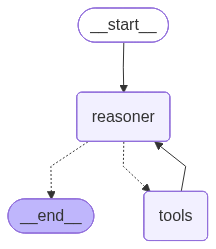

In [17]:
react_graph

In [18]:
messages=[HumanMessage(content="What is 2 times of narendra modi's age?")]

In [19]:
messages=react_graph.invoke({'messages': messages})

In [20]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times of narendra modi's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (functions.duckduckgo_search:0)
 Call ID: functions.duckduckgo_search:0
  Args:
    query: Narendra Modi age
================================= Tool Message =================================
Name: duckduckgo_search

Modiwas born and raised in Vadnagar, Bombay State (present-day Gujarat), where he completed his secondary education. He was introduced to the RSS at the age of eight, becoming a full-time worker for the organisation in Gujarat in 1971. Narendra Modi is the 15th and current Prime Minister of India, born on17 September 1950in Gujarat. He is a self-made leader who rose from a tea-seller to the top post of the BJP and the country. Sep 17, 2025 ·As PMModicelebrates his birthday today, September 17, social media is abuzz with wishes, greetings, curio

In [68]:
messages=[HumanMessage(content="What is the age of Elon Musk and the height of the Eiffel Tower in meters?")]

In [69]:
messages=react_graph.invoke({'messages': messages})

In [70]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the age of Elon Musk and the height of the Eiffel Tower in meters?
================================== Ai Message ==================================

I'll search for Elon Musk's age and the Eiffel Tower's height for you.
Tool Calls:
  duckduckgo_search (functions.duckduckgo_search:0)
 Call ID: functions.duckduckgo_search:0
  Args:
    query: Elon Musk age
  duckduckgo_search (functions.duckduckgo_search:1)
 Call ID: functions.duckduckgo_search:1
  Args:
    query: Eiffel Tower height meters
================================= Tool Message =================================
Name: duckduckgo_search

ElonMuskAgeBusinessmanElonMuskwas born on 28 June 1971 in Pretoria, Transvaal, South Africa. He is 54 years old as of 2025, and his zodiac sign is Cancer. ElonMuskis #1 on Forbes' 2026 Billionaires list. Read more aboutElonMusk, their experience, their asset summary, and more here. ElonMusk, Tesla and SpaceX

In [ ]:
messages=[HumanMessage(content="What is 2 times of narendra modi's age?")]

In [ ]:
!pip install yfinance

In [26]:
import yfinance as yf

In [27]:
def get_stock_price(ticker: str)->float:
    """Gets a stock price from Yahoo Finance.
    Args:
        ticker: ticker str."""
        
    # This is a tool for getting the proce of a stok when passed a ticker symbol
    stock=yf.Ticker(ticker)
    return stock.info['previousClose']

In [ ]:
get_stock_price("AAPL")

247.99

In [59]:
# Node
def reasoner(state):
    query=state['query']
    messages=state['messages']
    # System message
    sys_msg=SystemMessage(
    content="You are a helpful assistant tasked with using web search and performing arthmetic operations to answer questions. You have access to the following tools: add, multiply, divide, the yahoo  finanace tool and web_search. Use these tools to provide accurate and concise answers to the user's queries. you can provide any information to the user if asked for'"
    )
    message=HumanMessage(content=query)
    messages.append(message)
    result=[llm_with_tools.invoke([sys_msg] + messages)]
    return {'messages': result}

In [50]:
tools=[add, multiply, divide, web_search, get_stock_price]

In [51]:
llm_with_tools=llm.bind_tools(tools)

In [52]:
class GraphState(TypedDict):
    """State for the graph execution."""
    query: str
    finance: str
    final_answer: str
    
    messages: Annotated[list[AnyMessage], operator.add]

In [53]:
# Graph
workflow=StateGraph(GraphState)

# Adding nodes
workflow.add_node('reasoner', reasoner)
workflow.add_node('tools', ToolNode(tools)) #for the tools

# Adding edges
workflow.add_edge(START, 'reasoner')
workflow.add_conditional_edges(
    'reasoner',
    # If the latest message (result from reasoner) contains a tool call, go to the tools node
    # If the latest message does not contain a tool call, stay in the reasoner node to generate the final answer
    tools_condition,
)
workflow.add_edge('tools', 'reasoner')

In [54]:
react_graph=workflow.compile()

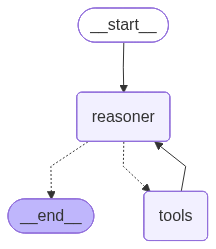

In [40]:
react_graph

In [41]:
response=react_graph.invoke({'query': "What is the stock price of Apple?", 'messages': []})

In [42]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of Apple?
================================== Ai Message ==================================

I'll get the current stock price of Apple for you.
Tool Calls:
  get_stock_price (functions.get_stock_price:0)
 Call ID: functions.get_stock_price:0
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

247.99
================================ Human Message =================================

What is the stock price of Apple?
================================== Ai Message ==================================

Apple's current stock price is $247.99.


In [45]:
response=react_graph.invoke({'query': "What is the stock price of Grow Company? and add 100 to it?", 'messages': []})

In [46]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of Grow Company? and add 100 to it?
================================== Ai Message ==================================

I'll help you find the stock price for Grow Company and add 100 to it. Let me search for the current stock price first.
Tool Calls:
  get_stock_price (functions.get_stock_price:0)
 Call ID: functions.get_stock_price:0
  Args:
    ticker: GROW
================================= Tool Message =================================
Name: get_stock_price

2.89
================================ Human Message =================================

What is the stock price of Grow Company? and add 100 to it?
================================== Ai Message ==================================

Now let me add 100 to the stock price:
Tool Calls:
  add (functions.add:1)
 Call ID: functions.add:1
  Args:
    a: 289
    b: 10000
================================= Tool Message ====================